# Aim of Notebook


This notebook constructs a structured BTS-focused Character.AI corpus from the Nomic Atlas dataset. It demonstrates dataset loading, metadata exploration of c.ai dataset, data quality assessment, and filtering of English-language BTS-related bots. The final output is a corpora of BTS character.ai bots for further analysis.

# 1. Setting up Notebook Environment


This section configures the Jupyter environment for corpus construction by facilitating automatic reloading of external Python modules (`autoreload`), importing core data science libraries (pandas, numpy, plotly) and HTML/display utilities for structured output inside the notebook

These tools support iterative development, especially when working with external scripts in the `scripts/` directory.

In [3]:
# core libraries
import os
import sys
import json
import numpy as np
import pandas as pd

#path
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parent  # notebook -> root
SCRIPTS_PATH = PROJECT_ROOT / "scripts" #scripts path

sys.path.append(str(PROJECT_ROOT))

# visualization
import plotly.express as px

# notebook display
from IPython.display import display, HTML
import html

# autoreload (optional)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Setting Up Nomic Atlas's Character.AI Dataset

This section connects the notebook to Nomic Atlas and loads the CAI dataset.

Steps performed:
- Adds the project root to the Python path so local modules in `scripts/` can be imported
- Imports and executes the `login_nomic()` function to authenticate with Nomic Atlas
- Loads the dataset using `load_nomic_dataset()` from `scripts/cai_nomic.py`

If successful:
- `df` contains the dataset as a pandas DataFrame
- `meta` contains dataset metadata (schema, source info, or annotations)

If loading fails:
- `df` is set to `None`
- an error message is printed for debugging


In [5]:
# -----------------------------
# Notebook setup for Nomic CAI Dataset
# -----------------------------

# add project root to Python path
sys.path.append(str(PROJECT_ROOT))
# import login function
from scripts.nomic_login import login_nomic

# log in to Nomic Atlas
login_nomic()

# import cai.dataset loading function
from scripts.cai_nomic import load_nomic_dataset

# try loading the dataset
try:
    df, meta = load_nomic_dataset()
    print(f"Dataset loaded successfully!")
except Exception as e:
    df = None
    print("Failed to load dataset:", e)


    

Login Successful!


2026-06-20 21:49:57.333 | INFO     | nomic.dataset:__init__:817 - Loading existing dataset `auth0thread765/all-cai-characters-`.
2026-06-20 21:49:58.324 | WARNING  | nomic.data_operations:df:1173 - Converting to pandas dataframe. This may materialize a large amount of data into memory.
2026-06-20 21:49:58.326 | INFO     | nomic.data_operations:_download_data:1142 - Downloading data
100%|████████████████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 4918.68it/s]
2026-06-20 21:49:59.686 | INFO     | nomic.data_operations:_load_data:1069 - Loading data
100%|██████████████████████████████████████████████████████████████████████████████████| 37/37 [00:02<00:00, 17.47it/s]


Dataset loaded successfully!


# 3. General Overview of Character.ai Dataset on Nomic

## 3.1 Metadata

Overview of dataset-level metadata including project details, access permissions, fields, and embedding configuration from Nomic Atlas.

In [6]:
display(HTML(f"""<h3>3.1 Metadata Summary</h3><br>"""))

#printing important metadata 
def metadata_summary(meta):
    print("DATASET INFORMATION")
    print(f"Project Name: {meta.get('project_name')}")
    print(f"Project ID: {meta.get('id')}")
    print(f"Creator / Owner Nickname: {meta.get('creator_nickname')}")
    print(f"Creator ID: {meta.get('creator')}")
    print(f"Organization: {meta.get('organization_name')}")
    print(f"Is Public: {meta.get('is_public')}")
    print(f"Privacy Level: {meta.get('privacy')}")
    print(f"Created Timestamp: {meta.get('created_timestamp')}")
    print(f"Total Data Points: {meta.get('total_datums_in_project'):,}")
    print()
    print("METADATA FIELDS")
    print("Project Fields:", ", ".join(meta.get('project_fields', [])))
    print(f"Unique ID Field: {meta.get('unique_id_field')}")
    print(f"Modality: {meta.get('modality')}")
    print()
    print("ACCESS / PERMISSIONS")
    print(f"Access Role: {meta.get('access_role')}")
    permissions = meta.get('permissions', {})
    print(f"Can Read Metadata: {permissions.get('dataset:metadata:read')}")
    print(f"Can Read Data: {permissions.get('dataset:data:read')}")
    print(f"Can Write / Edit Data: {permissions.get('dataset:data:write')}")
    print()
    print("NOMIC ATLAS EMBEDDINGS")
    for idx in meta.get('atlas_indices', []):
        print(f"Atlas Index Name: {idx.get('index_name')}")
        print(f"Indexed Field: {idx.get('indexed_field')}")
        print(f"Atoms: {', '.join(idx.get('atoms', []))}")
        print(f"Colorable Fields: {', '.join(idx.get('colorable_fields', []))}")
        for embed in idx.get('embedders', []):
            print(f"Embeddings Model: {embed.get('model_name')} (ready: {embed.get('ready')})")
    print()
    print("OTHER INFO")
    print(f"Slug: {meta.get('slug')}")
    print(f"Connector: {meta.get('connector_name')}")
    for m in meta.get('maps', []):
        print(f"Maps Data Points: {m.get('total_data_points')}")
    analyst_info = meta.get('analyst_info', {})
    print(f"Analyst Info: AI Subprocessor = {analyst_info.get('ai_subprocessor')}")


metadata_summary(meta)

DATASET INFORMATION
Project Name: All C.AI Characters 
Project ID: 153aa02c-6b4b-4723-858c-c3c8622d31fc
Creator / Owner Nickname: auth0.thread765
Creator ID: auth0|672181d2ac71294fbcfdb387
Organization: auth0.thread765
Is Public: True
Privacy Level: public
Created Timestamp: 2024-10-31T00:08:09.155322Z
Total Data Points: 783,978

METADATA FIELDS
Project Fields: avatar, name, description, expertise, personality_question, personality_answer, greeting, upvotes, interactions, categories, creator, language, participant, external_id, row_number
Unique ID Field: row_number
Modality: text

ACCESS / PERMISSIONS
Access Role: EXTERNAL
Can Read Metadata: True
Can Read Data: True
Can Write / Edit Data: False

NOMIC ATLAS EMBEDDINGS
Atlas Index Name: All C.AI Characters 
Indexed Field: description
Atoms: charchunk, document
Colorable Fields: avatar, name, expertise, personality_question, personality_answer, greeting, upvotes, interactions, categories, creator, language, participant, external_id
Embe

## 3.2 Database Size and Structure
Summary of dataset dimensions, column types, and structural layout to understand overall Nomic Atlas corpus composition.

In [7]:
#Dataset Size and Structure

total_rows, total_cols = df.shape
cols_df = df.dtypes.reset_index()           # convert series to df
cols_df.columns = ['Column', 'Data Type']  # column header

cols_html = cols_df.to_html(index=False, escape=False)
display(HTML(f"""<h3>3.2 Database Size and Column Structure</h3> 
<div style='display:flex; gap:30px; align-items:flex-start; margin-bottom:20px;'>

    <!-- Left card -->
    <div style='padding:20px; border-radius:12px; background:#069494; color:white; text-align:center; width:220px; box-shadow:0 4px 8px rgba(0,0,0,0.1);'>
        <div style='font-size:18px; font-weight:bold;'>Total Dataset</div>
        <div style='font-size:28px; font-weight:bold;'>{total_rows}</div>
        <div>Records</div>
        <div style='margin-top:5px; font-size:16px;'>{total_cols} Columns</div>
    </div>
    <!-- Right table -->
    <div style='flex:1; overflow-x:auto;'>
        <style>
            table {{
                border-collapse: collapse;
                width: 100%;
                min-width: 400px;
            }}
            th, td {{
                text-align: left;
                padding: 8px;
                white-space: nowrap;
            }}
            th {{
                background-color: #069494;
                color: white;
            }}
            tr:nth-child(even) {{
                background-color: #f2f2f2;
            }}
            tr:hover {{
                background-color: #d0f0f0;
            }}
        </style>
        {cols_html}
    </div>

</div>
"""))

Column,Data Type
row_number,str
personality_question,category
upvotes,int32
interactions,int32
categories,category
language,category
name,str
external_id,str
personality_answer,object
description,str


## 3.3 Random Sample Dataset Records

Display of randomly selected dataset entries to inspect structure, field consistency, and content quality.

In [8]:
display(HTML("<h3>3.3 Ten Sample Records Generated Randomly</h3>"))

sample_df = df.sample(10, random_state=42)

for _, row in sample_df.iterrows():

    display(HTML(
        "<div style='padding:10px; border:1px solid #ccc; border-radius:8px; margin-bottom:10px;'>"
        + "".join(
            f"<b>{html.escape(col.replace('_', ' ').title())}:</b> {html.escape(str(val))}<br>"
            for col, val in row.items()
        )
        + "</div>"
    ))

## 3.4 Percentage of Missing Values in Dataset

Column-wise analysis of missing data to identify sparsity patterns and assess feature reliability across the dataset.

C:\Users\chahn\AppData\Local\Temp\ipykernel_4012\3775405641.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df_null.select_dtypes(include=["object", "category"]).columns


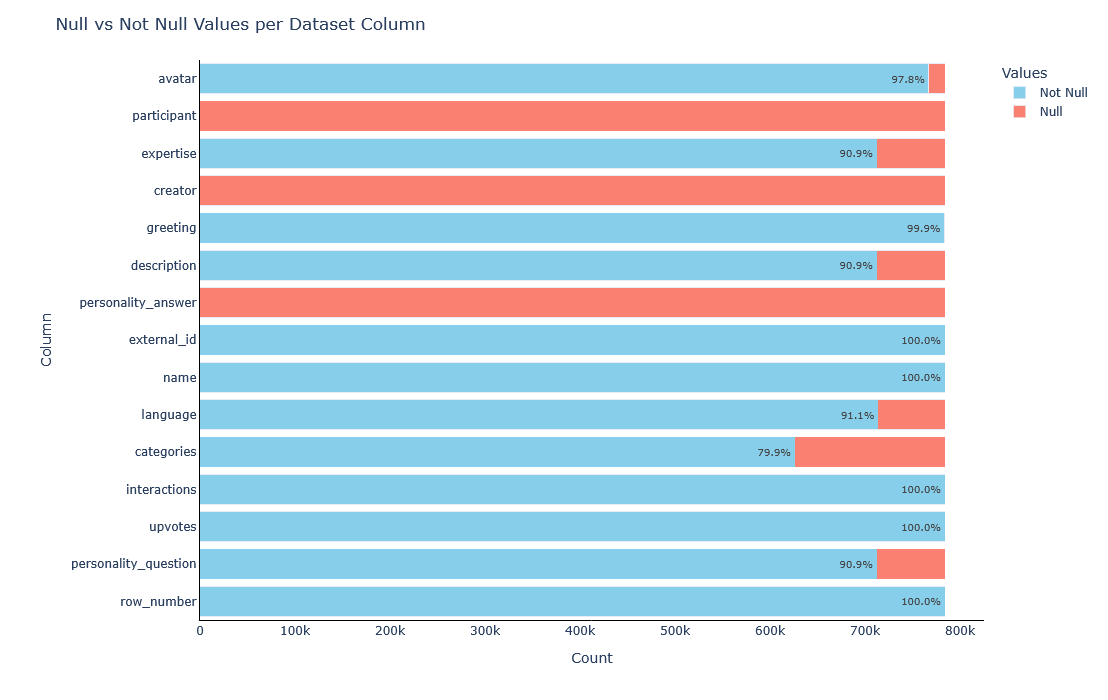

In [9]:
# 1. copy dataset for calculating missingness
df_null = df.copy()

# 2.normalize 'null' values 
object_cols = df_null.select_dtypes(include=["object", "category"]).columns
null_values = {"None", "none", "NULL", "null", "NaN", "nan", "na", "n/a", ""}

for col in object_cols:
    df_null[col] = df_null[col].replace(list(null_values), np.nan)

# in category dtype normalize null
cat_cols = df_null.select_dtypes(include=["category"]).columns

for col in cat_cols:
    df_null[col] = df_null[col].astype("object").replace("[]", np.nan)

# precompute missingness 
total = len(df_null)

df_plot = pd.DataFrame({
    "Column": df_null.columns,
    "Null": df_null.isna().sum().values,
    "Not Null": df_null.notna().sum().values
})


display(HTML("<h3>3.4 Percentage of Missing Values in Dataset (Per Column)</h3>"))

#melt for plotly 
df_melt = df_plot.melt(
    id_vars="Column",
    value_vars=["Not Null", "Null"],
    var_name="Values",
    value_name="Count"
)

# plot in plotly 
fig = px.bar(
    df_melt,
    y="Column",
    x="Count",
    color="Values",
    orientation="h",
    barmode="stack",
    color_discrete_map={
        "Not Null": "skyblue",
        "Null": "salmon"
    }
)

# show percent labels for non null in  each column
def add_percent_labels(trace):
    if trace.name == "Not Null":
        vals = df_plot["Not Null"].values
        perc = (vals / total * 100).round(1)
        trace.text = [f"{p}%" for p in perc]
    else:
        trace.text = None

fig.for_each_trace(add_percent_labels)

fig.update_traces(textposition="inside", textfont_size=10)

# display layout
fig.update_layout(
    title="Null vs Not Null Values per Dataset Column",
    height=700,
    width=1000,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=200),
    xaxis=dict(showline=True, linecolor="black"),
    yaxis=dict(showline=True, linecolor="black")
)

fig.show()

# 4. BTS Character Bots Corpus


Creation of structured BTS bot corpora, including member-wise subsets and a combined dataset sorted by popularity (upvotes).

## 4.1 Filtering BTS Bots

Filtering English language bts character bots by identifying band member names in bot name, greeting and description and sorting them by popularity (upvotes)

In [10]:

def filter_bts_bots(df, members=None):
    """
    Filter CAI dataset for BTS-related English bots.
    Args:
    df (pd.DataFrame): Full Nomic CAI dataset.
    members (list of str, optional): BTS member names to filter.

    
    Returns:
        bts_df (pd.DataFrame) df of all bts bots 
        member_counts (dict) bot counts 
    """
    #list of member names
    if members is None:
        members = ["Jungkook", "Taehyung", "Jimin", "Yoongi", "Namjoon", "Hoseok", "Seokjin"]

    pattern = "|".join(members)

    # Mask: true for bts member English-language bots that can be recognized by bot names, description or greeting 

    mask = (
        df["name"].str.contains(pattern, case=False, na=False) |
        df["description"].str.contains(pattern, case=False, na=False) |
        df["greeting"].str.contains(pattern, case=False, na=False)
    ) & (df["language"].str.lower() == "english")

    bts_df = df[mask].copy()

    #sort them by upvotes to see popular ones first
    bts_df.sort_values("upvotes", ascending=False, inplace=True)

    #count bots per member
    member_counts = {
        m: bts_df["name"].str.contains(m, case=False, na=False).sum()
        for m in members
    }

    return bts_df, member_counts

In [11]:
bts_df, counts = filter_bts_bots(df)

## 4.2 Saving Metadata CSV for Member Bots and All Members

Saving corpora for each member and a combined dataset in CSV 

In [13]:

def save_bts_bots(bts_df, members=None, save_dir=None):
    """
    Save BTS bot subsets per member + combined dataset with 'member' column.
    Outputs are sorted by upvotes (descending).
    """

    #project root
    PROJECT_ROOT = Path().resolve().parent

    #members
    if members is None:
        members = [
            "Jungkook", "Taehyung", "Jimin",
            "Yoongi", "Namjoon", "Hoseok", "Seokjin"
        ]

    # save dir
    if save_dir is None:
        save_dir = PROJECT_ROOT / "data" / "bts_bots"
    else:
        save_dir = Path(save_dir)

    save_dir.mkdir(parents=True, exist_ok=True)

    # check files
    existing_files = [
        f.name for f in save_dir.iterdir()
        if f.name.endswith("_bots_nomic.csv")
    ]

    overwrite = False

    if existing_files:
        print("Existing BTS bot files found:")
        print(", ".join(existing_files))

        while True:
            choice = input("Overwrite existing files? [y/n]: ").strip().lower()

            if choice == "y":
                overwrite = True
                break
            elif choice == "n":
                overwrite = False
                break
            else:
                print("Please enter 'y' or 'n'.")

    # build combined corpora
    all_dfs = []

    for m in members:
        member_df = bts_df[
            bts_df["name"].str.contains(m, case=False, na=False)
        ].copy()

        if member_df.empty:
            continue

        member_df["member"] = m
        all_dfs.append(member_df)

    total_df = (
        pd.concat(all_dfs, ignore_index=True)
        if all_dfs else pd.DataFrame()
    )

    if not total_df.empty:
        total_df = total_df.sort_values("upvotes", ascending=False)

    # save combined corpora
    combined_path = save_dir / "bts_all_members_bots.csv"

    if combined_path.exists() and not overwrite:
        print("Skipped combined dataset (already exists)")
    else:
        total_df.to_csv(combined_path, index=False)
        print(f"Saved combined dataset → {combined_path}")

    # save for each member 
    for m in members:
        member_df = total_df[total_df["member"] == m].copy()

        if member_df.empty:
            continue

        member_df = member_df.sort_values("upvotes", ascending=False)

        file_path = save_dir / f"{m.lower()}_bots_nomic.csv"

        if file_path.exists() and not overwrite:
            print(f"Skipped {file_path.name}")
            continue

        member_df.to_csv(file_path, index=False)
        print(f"Saved {len(member_df)} rows → {file_path}")

In [14]:
save_bts_bots(bts_df)

Existing BTS bot files found:
hoseok_bots_nomic.csv, jimin_bots_nomic.csv, jungkook_bots_nomic.csv, namjoon_bots_nomic.csv, seokjin_bots_nomic.csv, taehyung_bots_nomic.csv, yoongi_bots_nomic.csv


Overwrite existing files? [y/n]:  y


Saved combined dataset → E:\Jupyter_Programs\DH_Thesis\data\bts_bots\bts_all_members_bots.csv
Saved 817 rows → E:\Jupyter_Programs\DH_Thesis\data\bts_bots\jungkook_bots_nomic.csv
Saved 1161 rows → E:\Jupyter_Programs\DH_Thesis\data\bts_bots\taehyung_bots_nomic.csv
Saved 630 rows → E:\Jupyter_Programs\DH_Thesis\data\bts_bots\jimin_bots_nomic.csv
Saved 594 rows → E:\Jupyter_Programs\DH_Thesis\data\bts_bots\yoongi_bots_nomic.csv
Saved 222 rows → E:\Jupyter_Programs\DH_Thesis\data\bts_bots\namjoon_bots_nomic.csv
Saved 69 rows → E:\Jupyter_Programs\DH_Thesis\data\bts_bots\hoseok_bots_nomic.csv
Saved 84 rows → E:\Jupyter_Programs\DH_Thesis\data\bts_bots\seokjin_bots_nomic.csv


## 4.3 Number of BTS Bots 

Visualization of bot counts per BTS member to understand representation imbalance across the corpus.

In [17]:
colors = [
    "#FFADAD", "#FFD6A5", "#FDFFB6", "#CAFFBF",
    "#9BF6FF", "#A0C4FF", "#BDB2FF"
]
display(HTML(f"""<h3>4.3 BTS Kpop Boyband Bots on Character.ai </h3><br>"""))
# Generate HTML cards
html = "<div style='display:flex; gap:10px; flex-wrap:wrap;'>"
for i, (member, count) in enumerate(counts.items()):
    color = colors[i % len(colors)]
    card_html = f"""
    <div style='
        background-color:{color};
        padding:15px;
        border-radius:10px;
        width:110px;
        text-align:center;
        box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
        font-family:Arial, sans-serif;
    '>
        <h4 style='margin:5px 0;'>{member} </h4>
        <p style='margin:0; font-size:18px; font-weight:bold;'>{count}</p>
        <p style='margin:0; font-size:12px; color:#555;'>bots</p>
    </div>
    """
    html += card_html
html += "</div>"

# Display cards
display(HTML(html))

## 4.4 Sample Records Generated Randomly of BTS Bots by High Upvotes

Random selection of high-upvote bots to inspect high-quality or popular Character.AI entries across BTS members.

In [18]:


# display card for 5 random sample records
# Filter for bots with at least 100 upvotes
high_upvote_df = bts_df[bts_df["upvotes"] >= 100]

# Sample 5 rows randomly (with reproducibility)
sample_df = high_upvote_df.sample(5, random_state=577)
display(HTML(f"""<h3>4.4 Five Sample Records Generated Randomly </h3>"""))

#for this loop
#i took help of this documentation because i wasn't sure how to loop for each row
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.index.html#pandas.DataFrame.index
#by getting index of each row 
for i in sample_df.index:
    row = sample_df.loc[i]
    display(HTML(f"""<div style='padding:10px; border:1px solid #ccc; border-radius:8px; margin-bottom:10px;'>
        <b>Name:</b> {row['name']}<br>
        <b>Greeting:</b> {row['greeting']}<br>
        <b>Description:</b> {row['description']}<br>
        <b>Expertise:</b> {row['expertise']}<br>
        <b>Upvotes:</b> {row['upvotes']}<br>
        <b>Interactions:</b> {row['interactions']}<br>
        <b>Categories:</b> {row['categories']}<br>
        <b>Language:</b> {row['language']}<br>
        <b>Personality Question:</b> {row['personality_question']}<br>
        <b>Personality Answer:</b> {row['personality_answer']}<br>
        <b>Creator:</b> {row['creator']}<br>
        <b>Avatar:</b> {row['avatar']}<br>
        <b>ExternalID:</b> {row['external_id']}<br>
        <b>Row Number</b> {row['row_number']}<br>




    </div>
    """))